# NB2 - XGBoost 

## 1  Data Load and Prep

In [1]:
#load libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score
from Dataprep import preprocess_fit_transform
from xgboost import XGBClassifier
import shap
from sklearn.metrics import precision_recall_curve






/Users/lauragies/Documents/Job/NF_Bootcamp/capstone-kiezkeeper/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Load the features 
X_df = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})

#load the label for Module 2
labels = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})

#join left on plr_id 
df = X_df.merge(labels[["plr_id", "milieu_majoritaet"]], on="plr_id", how="left")


In [3]:
#sanity check
df.shape


(527, 46)

In [4]:
#sanity check 2 
df.columns


Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_leerstandsquote', 're_brw_niveau', 're_brw_trend', 're_dichte_all',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_average_household_size_2024',
       'soc_average_household_size_change_2021_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_unemployment_share_change_2020_2024',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benefit_share_change_2020_2024',
       'soc_single_parent_household_share_2024',
       'soc_single_parent_household_share_change_2021_2024',
       'com_median_age_level_2026', 'com_share_

In [5]:
#sanity check label

LABEL = "milieu_majoritaet"
assert df[LABEL].notna().all(), "Label enthält NaN — unerwartet."
assert set(df[LABEL].unique()) <= {0, 1}, "Label ist nicht binär 0/1."
print(df[LABEL].value_counts(), "\n")

milieu_majoritaet
0    418
1    109
Name: count, dtype: int64 



In [6]:
#define columns 
ID_COLS = ["plr_id", "plr_name", "bez"]   
GROUP_COL = "bez"

#Leakage guard: milieu_anteil is the continuous share the LABEL is derived from (>50% -> milieu_majoritaet)
#It must never enter the features. Not currently merged in, but excluded defensively; the assert below is the actual safeguard
LEAKAGE_COLS = ["milieu_anteil"]

feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + [LABEL] + LEAKAGE_COLS
]
assert not any("milieu" in c for c in feature_cols), \
    "Label-abgeleitete Spalte im Feature-Set — Leakage!"

In [7]:
#safeguard plr_id as string with 8 digits 
df["plr_id"] = df["plr_id"].astype(str).str.zfill(8)

X = df[feature_cols].copy()
y = df[LABEL].astype(int).to_numpy()           
groups = df[GROUP_COL].to_numpy()
plr_ids = df["plr_id"].to_numpy()

# Sanity-Checks 
assert len(X) == len(y) == len(groups) == len(plr_ids)
assert df["plr_id"].is_unique, "plr_id not unambiguous!"
n_pos = int(y.sum())
print(f"\nPositive: {n_pos} | Negative: {len(y) - n_pos} | positive rate: {n_pos/len(y):.1%}")



Positive: 109 | Negative: 418 | positive rate: 20.7%


## 2 XGBoost Out of Fold 

In [8]:
#Per fold: XGBoost OOF (tree-based, no scaling, no log)
n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

#OOF-Array: one probability per PLR
oof_prob_xgb = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_train = y[train_idx]

    #fold-wise preprocessing: impute only (no scaling, no log for trees)
    X_train_prep, X_val_prep = preprocess_fit_transform(
        X_train, X_val, feature_cols, log_cols=[], scale=False
    )

    #class imbalance handled per fold, analogous to class_weight='balanced'
    n_pos = int(y_train.sum())
    n_neg = len(y_train) - n_pos
    spw = n_neg / n_pos

    #XGBoost with untuned defaults as starting point; only imbalance + reproducibility set
    model = XGBClassifier(
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1,
        eval_metric="aucpr",
    )
    model.fit(X_train_prep, y_train)
    oof_prob_xgb[val_idx] = model.predict_proba(X_val_prep)[:, 1]

    #fold diagnosis
    fold_ap = average_precision_score(y[val_idx], oof_prob_xgb[val_idx])
    n_pos_val = int(y[val_idx].sum())
    print(f"Fold {fold}: n_val={len(val_idx):3d} | n_pos={n_pos_val:2d} | "
          f"pos_rate={n_pos_val/len(val_idx):.1%} | spw={spw:.2f} | AUC-PR={fold_ap:.3f} | "
          f"Bezirke={np.unique(groups[val_idx])}")
    
#Check for full OOF-coverage
assert not np.isnan(oof_prob_xgb).any(), "Not every PLR has an OOF prediction"

Fold 1: n_val= 96 | n_pos=19 | pos_rate=19.8% | spw=3.79 | AUC-PR=0.859 | Bezirke=['03 - Pankow' '10 - Marzahn-Hellersdorf']
Fold 2: n_val= 92 | n_pos= 8 | pos_rate=8.7% | spw=3.31 | AUC-PR=0.321 | Bezirke=['04 - Charlottenburg-Wilmersdorf' '11 - Lichtenberg']
Fold 3: n_val=125 | n_pos=19 | pos_rate=15.2% | spw=3.47 | AUC-PR=0.691 | Bezirke=['01 - Mitte' '09 - Treptow-Köpenick' '12 - Reinickendorf']
Fold 4: n_val= 91 | n_pos=17 | pos_rate=18.7% | spw=3.74 | AUC-PR=0.682 | Bezirke=['05 - Spandau' '07 - Tempelhof-Schöneberg']
Fold 5: n_val=123 | n_pos=46 | pos_rate=37.4% | spw=5.41 | AUC-PR=0.900 | Bezirke=['02 - Friedrichshain-Kreuzberg' '06 - Steglitz-Zehlendorf'
 '08 - Neukölln']


In [9]:
#pooled AUC-PR + export OOF probabilities
oof_df_xgb = pd.DataFrame({
    "plr_id": plr_ids,
    "y_true": y,
    "oof_prob": oof_prob_xgb,
})

overall_ap_xgb = average_precision_score(y, oof_prob_xgb)
baseline_ap = y.mean()
print(f"\nXGBoost pooled AUC-PR: {overall_ap_xgb:.3f}  (Baseline = {baseline_ap:.3f})")

oof_df_xgb.to_csv("../../models/M_oof_xgboost.csv", index=False)


XGBoost pooled AUC-PR: 0.676  (Baseline = 0.207)


## Result Discussion - Performance 

XGBoost reaches a pooled out-of-fold AUC-PR of 0.676, far above the no-skill baseline of 0.207. Its performance tracks the number of positives per fold almost monotonically — strongest on the data-rich Friedrichshain-Kreuzberg / Steglitz- Zehlendorf / Neukölln fold (46 positives, 0.90) and weakest on Charlottenburg- Wilmersdorf / Lichtenberg (only 8 positives, 0.32) — confirming the pattern already seen for logistic regression, that fold strength reflects label density rather than model capacity. 

Hyperparameter tuning was deliberately skipped: with only 109 positives across 42 features the expected gain is small, and tuning under GroupKFold would require a nested inner loop to avoid leaking validation information into model selection. An honest untuned model is also the more defensible choice under the positive-unlabeled label, since a higher AUC-PR would mainly mean the model reproduces the existing (incomplete, politically fragmented) designation map more closely — which is not the project's goal.

## 3 Model comparison: LogReg vs. XGBoost 

In [10]:
#LogReg vs. XGBoost on identical folds & preprocessing 
logreg_oof = pd.read_csv("../../models/M_oof_logreg.csv", dtype={"plr_id": str})
xgb_oof    = pd.read_csv("../../models/M_oof_xgboost.csv", dtype={"plr_id": str})

#align on plr_id so we compare the same PLR in the same order
merged = logreg_oof.merge(
    xgb_oof, on="plr_id", suffixes=("_logreg", "_xgb")
)

#sanity: labels must match across the two files
assert (merged["y_true_logreg"] == merged["y_true_xgb"]).all(), \
    "y_true differs between the two OOF files — check the merge/label."

y_true = merged["y_true_logreg"].to_numpy()
baseline_ap = y_true.mean()
ap_logreg = average_precision_score(y_true, merged["oof_prob_logreg"])
ap_xgb    = average_precision_score(y_true, merged["oof_prob_xgb"])

print("Pooled AUC-PR (out-of-fold, GroupKFold by Bezirk)")
print(f"  Baseline (no skill): {baseline_ap:.3f}")
print(f"  LogReg:              {ap_logreg:.3f}")
print(f"  XGBoost:             {ap_xgb:.3f}")
print(f"  Difference:          {ap_xgb - ap_logreg:+.3f}")

Pooled AUC-PR (out-of-fold, GroupKFold by Bezirk)
  Baseline (no skill): 0.207
  LogReg:              0.628
  XGBoost:             0.676
  Difference:          +0.048


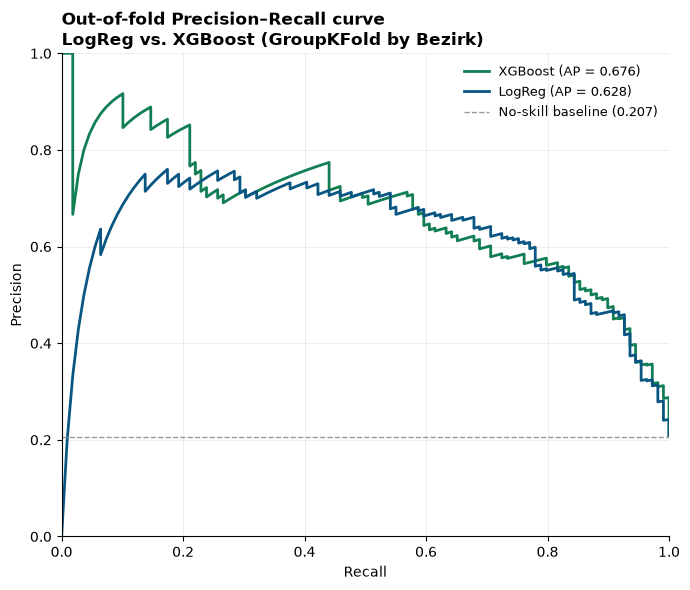

In [11]:
#Precision–Recall curve: visualizes what the pooled AUC-PR summarizes
#reuse merged / y_true / ap_logreg / ap_xgb / baseline_ap from the comparison cell above

prec_lr,  rec_lr,  _ = precision_recall_curve(y_true, merged["oof_prob_logreg"])
prec_xgb, rec_xgb, _ = precision_recall_curve(y_true, merged["oof_prob_xgb"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_xgb, prec_xgb, color="#117F53", lw=2, label=f"XGBoost (AP = {ap_xgb:.3f})")
ax.plot(rec_lr,  prec_lr,  color="#095682", lw=2, label=f"LogReg (AP = {ap_logreg:.3f})")
ax.axhline(baseline_ap, color="#999999", ls="--", lw=1,
           label=f"No-skill baseline ({baseline_ap:.3f})")

ax.set_xlabel("Recall", fontsize=10)
ax.set_ylabel("Precision", fontsize=10)
ax.set_title("Out-of-fold Precision–Recall curve\n"
             "LogReg vs. XGBoost (GroupKFold by Bezirk)",
             fontsize=12, fontweight="bold", loc="left")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25, lw=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../../plots/pr_curve_logreg_vs_xgb.png", dpi=200, bbox_inches="tight")
plt.show()

### Result Discussion - Performance Comparison 

On identical folds and preprocessing, XGBoost's pooled AUC-PR of 0.676 exceeds logistic regression's 0.628 by a modest +0.048, with both far above the 0.207 baseline. The small size of the gain is itself reassuring: with only 109 positives across 42 features, a large jump would more likely signal overfitting than genuine skill; the modest gain is instead consistent with the tree model capturing some real non-linear structure the linear baseline misses.

Crucially, both models fail on the same low-count fold and succeed on the same data-rich one, which isolates the weak fold as a property of the data rather than a limitation of the linear model. The honest summary is therefore that XGBoost is better where the data are sufficient and equally constrained where they are not.

The precision–recall curve shows the advantage is concentrated at low recall: among the highest-ranked PLR, XGBoost holds ~0.85–0.90 precision against roughly 0.75 for logistic regression, before the two converge beyond recall ≈ 0.5  and decline together toward the baseline. This matters for the platform, since the watchlist is built from exactly these top-ranked, high-confidence cases — the region where the tree model is most clearly ahead.

In [12]:
#SHAP for XGBoost: recover direction + magnitude (raw gain gives magnitude only)
#Refit on ALL rows for one interpretable model (mirrors m_all in NB1; fold models vary)

X_shap, _ = preprocess_fit_transform(X, X, feature_cols, log_cols=[], scale=False)

n_pos_all = int(y.sum())
spw_all = (len(y) - n_pos_all) / n_pos_all

model_shap = XGBClassifier(
    scale_pos_weight=spw_all,
    random_state=42,
    n_jobs=-1,
    eval_metric="aucpr",
)
model_shap.fit(X_shap, y)

#TreeExplainer: exact and fast for tree models
explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_shap)

#pretty feature names (strip dimension prefix, underscores -> spaces)
def pretty(f):
    for p in ("soc_", "re_", "com_"):
        if f.startswith(p):
            f = f[len(p):]
    return f.replace("_", " ")
pretty_names = [pretty(c) for c in feature_cols]

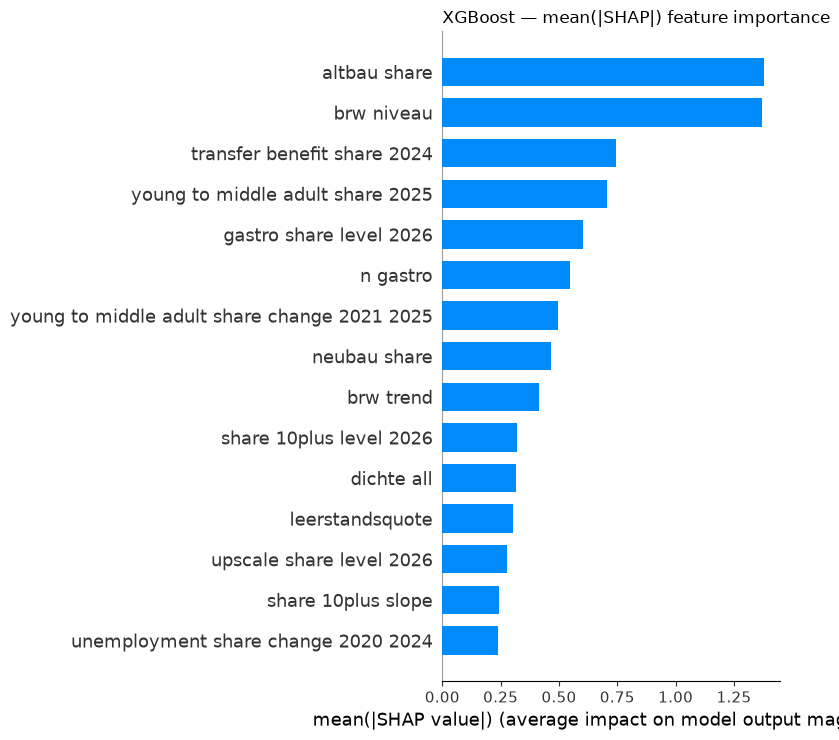

In [13]:
#Bar: mean(|SHAP|) per feature — magnitude ranking, comparable to LogReg |coef|
shap.summary_plot(shap_values, X_shap, feature_names=pretty_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("XGBoost — mean(|SHAP|) feature importance", fontsize=12, loc="left")
plt.tight_layout()
plt.savefig("../../plots/xgb_shap_bar.png", dpi=200, bbox_inches="tight")
plt.show()

### Result Discussion - SHAP Magnitude

This plot ranks features by mean absolute SHAP value, the tree-based analog to the standardized |coefficient| ranking from the logistic regression: it measures how much each feature moves the model's output on average, without indicating direction. 

The top cluster is dominated by altbau share and BRW niveau, followed at roughly half the magnitude by transfer-benefit share and young-to-middle adult share. The overlap with the logistic regression is substantial — BRW niveau, transfer-benefit share, and young-to-middle adult share rank near the top in both models — a genuine robustness signal, since two structurally different model families independently identify the same variables as most informative.

The clearest divergence is altbau share, mid-ranked in the linear model but first here (the commercial gastronomy features show the same pattern more weakly). This suggests its predictive value is largely non-linear: it carries little signal alone but becomes highly informative in combination with other features — exactly the interaction a tree ensemble captures and a linear coefficient cannot. It is a concrete illustration of why XGBoost edges out the baseline: the gain comes not from ranking different variables, but from extracting more from the same ones through interactions and thresholds. 

One caveat carries over from the linear analysis: altbau share's prominence partly reflects that Milieuschutz policy explicitly targets Altbau-heavy areas, so it predicts designation rather than causing gentrification.

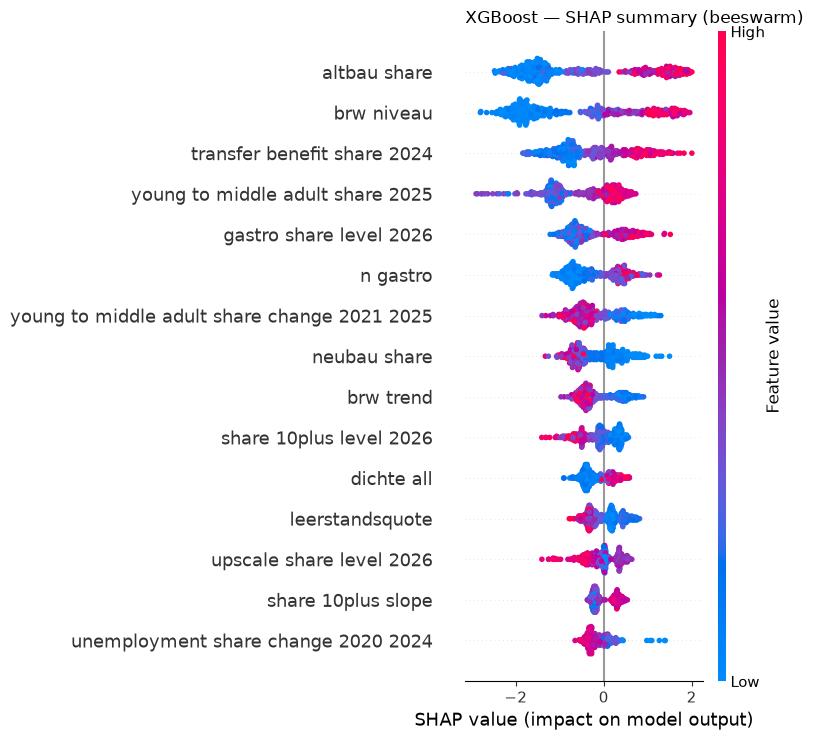

In [14]:
#Beeswarm: each dot = one PLR; x = SHAP value (impact on designation odds),
#color = feature value (red = high, blue = low)
shap.summary_plot(shap_values, X_shap, feature_names=pretty_names,
                  max_display=15, show=False)
plt.title("XGBoost — SHAP summary (beeswarm)", fontsize=12, loc="left")
plt.tight_layout()
plt.savefig("../../plots/xgb_shap_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()

### Result Discussion - SHAP Direction

The beeswarm adds what the bar plot omits: each dot is one PLR, its horizontal position is the feature's push toward (right) or away from (left) resembling a designated area, and its color encodes the feature value (red high, blue low).

Where features overlap with the logistic regression, the directions agree — high transfer-benefit share, high young-to-middle adult share, high BRW niveau, and high altbau share all push toward designation, while high new construction, high vacancy, and a rising young-to-middle adult share push away — confirming the linear findings under a completely different model. 

Crucially, the level-versus- change divergence survives in XGBoost: the young-to-middle adult share level pushes toward designation while its 2021–2025 change pushes away, the same early-warning signal the linear model surfaced. 

The clearest non-linearity appears in BRW niveau and altbau share, where the point cloud is asymmetric and clustered rather than a smooth low-to-high gradient — this is structure a single linear coefficient cannot represent, and it plausibly explains XGBoost's modest
+0.048 AUC-PR edge. 

Two caveats: this uses the full-data refit, so it describes what the model learned overall rather than out-of-fold generalization, and as before these are associations with designation, not causal drivers of gentrification.

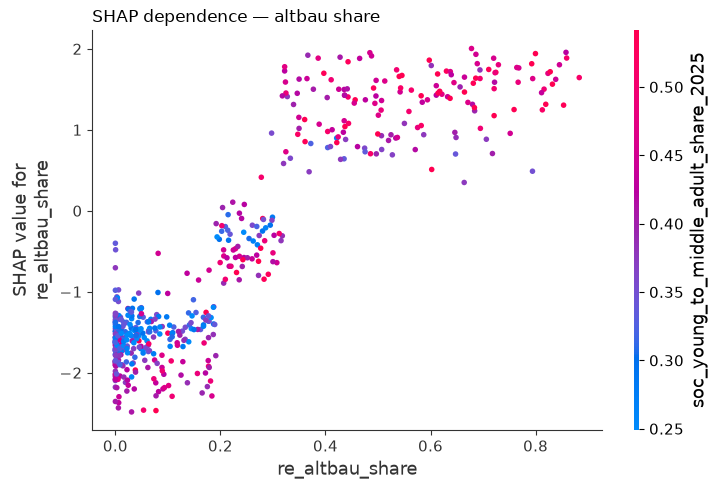

In [15]:
#Check hypothesis: SHAP dependence plot: does altbau share act non-linearly / via interaction?
#x = raw feature value, y = its SHAP value, color = the feature it interacts with most
shap.dependence_plot(
    "re_altbau_share",          # original column name in X_shap
    shap_values,
    X_shap,
    interaction_index="auto",   # SHAP picks the strongest interacting feature and colors by it
    show=False,
)
plt.title("SHAP dependence — altbau share", fontsize=12, loc="left")
plt.tight_layout()
plt.savefig("../../plots/xgb_shap_dependence_altbau.png", dpi=200, bbox_inches="tight")
plt.show()

### Plot Discussion 

A dependence plot confirms this directly: altbau share acts through a threshold near 0.3 — below it the contribution is flat and negative, above it sharply positive — rather than the smooth gradient a linear coefficient assumes. 

The colouring also shows a clear interaction with the young-to-middle adult share: high Altbau combined with a high share of young adults produces the strongest push toward designation, so the feature's value genuinely depends on the company it keeps. This is why a single linear coefficient underrates altbau share while the tree ensemble ranks it first.